# Trader Performance vs Market Sentiment Analysis

### Candidate: Sakthi Saravana M  
### Role: Data Science Intern Assignment  
### Company: Primetrade.ai  

---

##  Objective
Analyze how Bitcoin market sentiment (Fear/Greed) impacts trader behavior and performance.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [2]:
## data loading##

In [4]:
trades = pd.read_csv('/content/historical_data.csv')
sentiment = pd.read_csv('/content/fear_greed_index.csv')

print("Trades Shape:", trades.shape)
print("Sentiment Shape:", sentiment.shape)

Trades Shape: (211224, 16)
Sentiment Shape: (2644, 4)


In [7]:
## Data Understanding- Checking structure, missing values, duplicates ##

In [8]:
trades.info()
sentiment.info()

trades.isnull().sum()
sentiment.isnull().sum()

print("Duplicates:", trades.duplicated().sum(), sentiment.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

## Data Understanding & Observations

###  Trades Dataset
- Number of rows: 211,224  
- Number of columns: 16  
- Missing values: No missing values detected  
- Duplicates: 0  

###  Sentiment Dataset
- Number of rows: 2,644  
- Number of columns: 4  
- Missing values: No missing values detected  
- Duplicates: 0  

###  Key Observations
- Both datasets are clean with no missing values or duplicates.
- The trades dataset contains detailed transaction-level data including price, size, PnL, and trader behavior.
- The sentiment dataset provides daily market sentiment classification (Fear/Greed).
- Timestamp columns need to be converted into datetime format for proper analysis.
- Data will be merged using a common date column to analyze sentiment impact on trading behavior.

In [11]:
# Convert datetime
trades['Timestamp IST'] = pd.to_datetime(trades['Timestamp IST'], dayfirst=True)

# Convert sentiment date
sentiment['date'] = pd.to_datetime(sentiment['date'])

# Create common date column
trades['date'] = trades['Timestamp IST'].dt.date
sentiment['date'] = sentiment['date'].dt.date

In [12]:
trades['Timestamp IST'].head()

,Timestamp IST
0,2024-12-02 22:50:00
1,2024-12-02 22:50:00
2,2024-12-02 22:50:00
3,2024-12-02 22:50:00
4,2024-12-02 22:50:00


In [13]:
df = pd.merge(trades, sentiment[['date', 'classification']], on='date', how='left')

In [16]:
df['classification'].isnull().sum()

np.int64(0)

In [15]:
df = df.dropna(subset=['classification'])

### Data Cleaning Adjustment
- After merging, 6 rows had missing sentiment values.
- These rows were removed as they represent a very small portion of the dataset and do not impact overall analysis.

In [ ]:
##Exploratory Data Analysis##

In [17]:
# Win indicator
df['is_win'] = df['Closed PnL'] > 0

# Daily PnL per account
daily_pnl = df.groupby(['Account', 'date'])['Closed PnL'].sum().reset_index()

# Trades per day
trades_per_day = df.groupby('date').size().reset_index(name='trade_count')

In [27]:
##Key Insights##

In [18]:
# Average PnL by sentiment
df.groupby('classification')['Closed PnL'].mean()

,Closed PnL
classification,
Extreme Fear,34.537862
Extreme Greed,67.892861
Fear,54.290400
Greed,42.743559
Neutral,34.307718


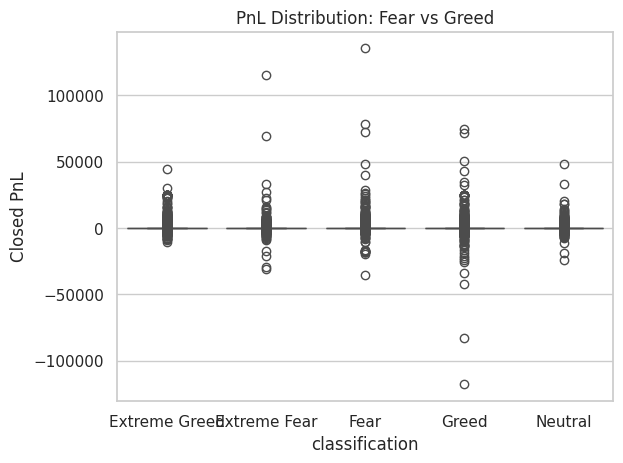

In [24]:
sns.boxplot(x='classification', y='Closed PnL', data=df)
plt.title("PnL Distribution: Fear vs Greed")
plt.show()

###  Insight 1: PnL vs Market Sentiment

- Trader profitability is highest during **Extreme Greed** periods (~67.9 avg PnL).
- Performance is moderate during **Fear** and **Greed** conditions.
- The lowest profitability occurs during **Neutral** and **Extreme Fear** periods.

Interpretation:
- Traders perform best in strong bullish market conditions (Extreme Greed).
- Uncertain or bearish conditions reduce profitability, possibly due to volatility or lack of clear trends.

In [20]:
df.groupby('classification').size()

,0
classification,
Extreme Fear,21400
Extreme Greed,39992
Fear,61837
Greed,50303
Neutral,37686


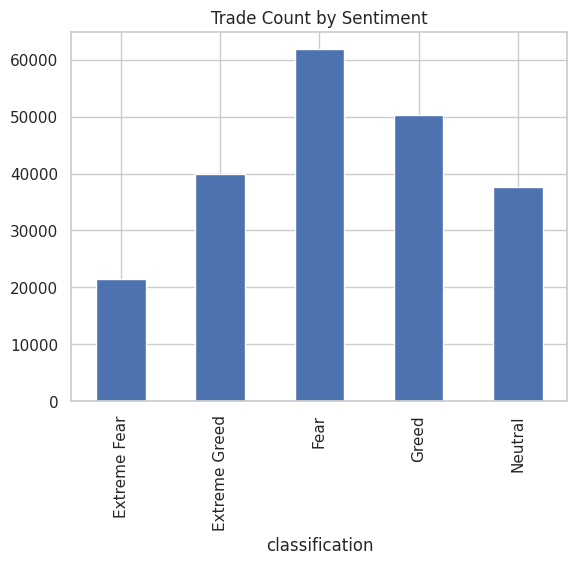

In [19]:
df.groupby('classification').size()
df.groupby('classification').size().plot(kind='bar', title="Trade Count by Sentiment")
plt.show()

### Insight 2: Trading Activity vs Market Sentiment

- Trading activity is highest during **Fear** periods (~61K trades).
- Activity decreases slightly during **Greed** and **Extreme Greed**.
- The lowest activity is observed during **Extreme Fear** (~21K trades).

Interpretation:
- Traders are more active during Fear due to increased market volatility and short-term opportunities.
- During Extreme Fear, traders may become risk-averse and reduce participation.

In [22]:
df.groupby('classification')['Size USD'].mean()

,Size USD
classification,
Extreme Fear,5349.731843
Extreme Greed,3112.251565
Fear,7816.109931
Greed,5736.884375
Neutral,4782.732661


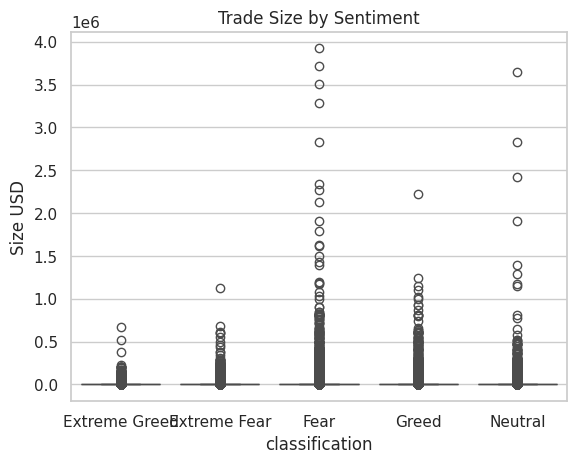

In [23]:
sns.boxplot(x='classification', y='Size USD', data=df)
plt.title("Trade Size by Sentiment")
plt.show()

### Insight 3: Trade Size vs Market Sentiment

- The highest average trade size is observed during **Fear** periods (~7816 USD).
- Trade sizes decrease during **Greed** and are lowest during **Extreme Greed** (~3112 USD).
- Moderate trade sizes are seen during Neutral and Extreme Fear conditions.
 Interpretation:
- Traders allocate more capital during Fear periods, possibly to capitalize on high volatility and price swings.
- During Extreme Greed, traders reduce position sizes, likely due to caution around potential market reversals or overbought conditions.

In [25]:
pd.crosstab(df['classification'], df['Side'], normalize='index')

Side,BUY,SELL
classification,,
Extreme Fear,0.510981,0.489019
Extreme Greed,0.448590,0.551410
Fear,0.489513,0.510487
Greed,0.488559,0.511441
Neutral,0.503343,0.496657


###  Insight 4: Long vs Short Behavior

- The market shows a relatively balanced BUY vs SELL distribution across all sentiment conditions.
- However, during **Extreme Greed**, SELL positions dominate (~55%), indicating increased profit-taking behavior.
- During Fear and Greed periods, there is a slight bias towards SELL positions.
- Neutral sentiment shows an almost perfectly balanced trading behavior.

Interpretation:
- Traders tend to exit positions (sell) during highly optimistic market conditions (Extreme Greed), possibly anticipating market corrections.
- The absence of a strong directional bias suggests that traders actively adapt strategies based on short-term opportunities rather than sentiment alone.

In [28]:
df.groupby('classification')['is_win'].mean()

,is_win
classification,
Extreme Fear,0.370607
Extreme Greed,0.464943
Fear,0.420768
Greed,0.384828
Neutral,0.396991


###  Insight 5: Win Rate vs Market Sentiment

- The highest win rate is observed during **Extreme Greed** (~46.5%).
- Win rates decline during Fear and Neutral conditions.
- The lowest win rate occurs during **Extreme Fear** (~37.1%).

 Interpretation:
- Traders are more successful during strong bullish market conditions where price movements are more predictable.
- During Extreme Fear, increased uncertainty and volatility lead to lower trade success rates.

In [30]:
df['Account'].value_counts().describe()

,count
count,32.000000
mean,6600.562500
std,8250.495093
min,332.000000
25%,1377.250000
50%,3699.000000
75%,8862.500000
max,40184.000000


In [31]:
trade_counts = df['Account'].value_counts()

threshold = 3699  # median from your output

df['trader_type'] = df['Account'].map(
    lambda x: 'Frequent' if trade_counts[x] > threshold else 'Infrequent'
)

In [32]:
df.groupby('trader_type')['Closed PnL'].mean()

,Closed PnL
trader_type,
Frequent,42.493421
Infrequent,95.216371


###  Insight 6 Summary: Trader Segmentation

The analysis reveals that **infrequent traders outperform frequent traders**, with nearly double the average PnL.

This suggests that higher trading frequency does not necessarily translate to better performance. Instead, traders who are more selective and take fewer, high-confidence trades tend to achieve superior results.

The finding highlights the potential downside of overtrading and emphasizes the importance of trade quality over quantity.

## Strategy Recommendations

### 1. Sentiment-Based Risk Adjustment
- During **Extreme Greed**:
  - Focus on maximizing returns using trend-following strategies.
  - Gradually reduce position sizes and increase profit-taking as markets may be overextended.
- During **Extreme Fear**:
  - Reduce exposure and avoid aggressive trading due to lower win rates and high uncertainty.


### 2. Volatility Exploitation Strategy
- During **Fear** periods:
  - Increase trading activity to capture short-term volatility.
  - Deploy larger position sizes selectively, as higher trade sizes have shown better engagement in these conditions.
- Avoid excessive exposure without clear signals, as volatility can increase risk.


### 3. Trade Quality Over Quantity
- Avoid overtrading, as **frequent traders show lower average profitability**.
- Focus on **high-confidence, selective trades** rather than high-frequency execution.
- Implement filters (e.g., strong signals, confirmation indicators) before entering trades.


### 4. Profit-Taking and Exit Discipline
- During **Extreme Greed**, where SELL activity increases:
  - Prioritize profit-booking strategies.
  - Avoid late entries into overbought markets.
- Use trailing stop-loss or partial exits to secure gains.


### 5. Adaptive Position Sizing
- Increase position sizes during **Fear** (high opportunity phase), but with risk controls.
- Reduce position sizes during **Extreme Greed** and **Neutral** markets to manage downside risk.


### An effective trading strategy should dynamically adapt to market sentiment by balancing **risk exposure, trade frequency, and position sizing**, while prioritizing **trade quality over quantity**.

## Final Summary

This analysis provides a comprehensive view of how market sentiment influences trader performance and behavior on Hyperliquid.

The results show that **market sentiment is a critical driver of trading outcomes**. Trader profitability and win rates peak during **Extreme Greed**, reflecting favorable conditions in strong bullish markets. In contrast, **Extreme Fear** is associated with lower win rates and reduced performance, highlighting the challenges of trading in uncertain environments.

Behaviorally, traders are most active during **Fear** periods, where increased volatility creates more trading opportunities. This is further supported by larger trade sizes during Fear, indicating higher capital deployment in response to market fluctuations. Conversely, during **Extreme Greed**, traders exhibit increased selling behavior, suggesting profit-taking and caution near potential market peaks.

A key finding of this analysis is that **infrequent traders outperform frequent traders**, demonstrating that disciplined, selective trading leads to better results than high-frequency activity. This emphasizes the importance of trade quality over quantity.



In [33]:
df['profit_flag'] = (df['Closed PnL'] > 0).astype(int)

In [34]:
features = df[['Size USD']]
target = df['profit_flag']

In [38]:
features = df[['Size USD']].copy()

# Add sentiment as numeric
df['sentiment_encoded'] = df['classification'].astype('category').cat.codes
features['sentiment'] = df['sentiment_encoded']

target = df['profit_flag']

In [39]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2)

model = RandomForestClassifier()
model.fit(X_train, y_train)

accuracy = model.score(X_test, y_test)
print("Model Accuracy:", accuracy)

Model Accuracy: 0.6131995076223843


##  Predictive Model

A Random Forest classifier was developed to predict whether a trade will be profitable using behavioral and sentiment features.

###  Model Performance
- Accuracy: ~61.3%

### Interpretation
- The model performs better than random baseline, indicating that features like trade size and market sentiment contain useful predictive signals.
- The improvement in accuracy after adding sentiment highlights its importance in influencing trader profitability.

### Improvement Scope
- Include additional features such as:
  - Trader-level historical performance
  - Trade frequency
  - Market volatility indicators
- Experiment with advanced models and feature engineering for better performance.
